# 02 — Factor & Residual Analysis

Computes **factor scores** (momentum, value, quality, growth) for every stock, runs **OLS market/sector regressions**, extracts residuals, and clusters the universe via **PCA** and **hierarchical clustering**.

**Inputs:** `data/prices.parquet`, `data/returns.parquet`, `data/fundamentals.parquet`  
**Outputs:** `data/factor_scores.parquet`, `data/betas.parquet`, `data/residuals.parquet`

In [2]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
sys.path.insert(0, '.')
from config import *
print('Ready.')

Ready.


In [3]:
prices   = pd.read_parquet(DATA_DIR + 'prices.parquet')
returns  = pd.read_parquet(DATA_DIR + 'returns.parquet')
fund_df  = pd.read_parquet(DATA_DIR + 'fundamentals.parquet')

ALL_STOCKS  = [LONG_CANDIDATE] + SHORT_CANDIDATES
ALL_TICKERS = ALL_STOCKS + [SECTOR_ETF, MARKET_INDEX]

stock_px  = prices[ALL_STOCKS]
stock_ret = returns[ALL_STOCKS]
mkt_ret   = returns[MARKET_INDEX]
sec_ret   = returns[SECTOR_ETF]

print(f'Prices : {prices.shape}')
print(f'Returns: {returns.shape}')
print(f'Funds  : {fund_df.shape}')
print(f'Universe: {ALL_STOCKS}')

Prices : (984, 26)
Returns: (983, 26)
Funds  : (24, 20)
Universe: ['GEVO', 'CHPT', 'BE', 'RUN', 'ARRY', 'HYLN', 'RIVN', 'LCID', 'GOEV', 'ALTO', 'REI', 'PARR', 'PDM', 'VNO', 'CLPR', 'BBWI', 'AFRM', 'UPST', 'BBAI', 'SOUN', 'PACB', 'GPRE', 'PLUG', 'AMTX']


## 1. Factor Scores

| Factor | Proxy |
|---|---|
| **Momentum** | 12-1 month total return |
| **Short Momentum** | 1-month return |
| **Value** | 1 / Forward P/E (normalized) |
| **Quality** | ROE - Debt/Equity ratio (normalized) |
| **Growth** | Revenue growth YoY (normalized) |
| **Low Vol** | Negative of 1-year realized vol |

In [4]:
def zscore_cross_section(series):
    """Cross-sectional z-score (rank-based for robustness)."""
    return series.rank().sub(series.rank().mean()).div(series.rank().std())

# ── Momentum factors (price-based) ───────────────────────────────────────────
days_12m = min(252, len(stock_px) - 1)
days_1m  = min(21,  len(stock_px) - 1)

momentum_12_1 = stock_px.pct_change(days_12m - 21).iloc[-1]   # 12m excl. last month
momentum_1m   = stock_px.pct_change(days_1m).iloc[-1]          # 1-month

# ── Volatility (low-vol factor = negative of vol) ────────────────────────────
low_vol = -(stock_ret.std() * np.sqrt(252))

print('Price-based factors:')
pd.DataFrame({
    'Momentum 12-1': momentum_12_1,
    'Momentum 1m':   momentum_1m,
    'Low Vol':        low_vol
}).round(4)

Price-based factors:


,Momentum 12-1,Momentum 1m,Low Vol
Ticker,,,
GEVO,1.4159,0.4368,-0.9305
CHPT,-0.6290,-0.2442,-0.8169
BE,6.1650,-0.1838,-0.8632
RUN,0.8275,0.0831,-0.9482
ARRY,0.3667,-0.0449,-0.8222
HYLN,0.0932,-0.2108,-0.8800
RIVN,0.1316,0.0027,-0.7376
LCID,-0.6277,-0.0499,-0.7960
GOEV,0.0000,0.0000,-1.1731


In [7]:
# ── Fundamental factors ──────────────────────────────────────────────────────
# fund_df is saved with tickers as index rows; reindex handles missing tickers gracefully
fund_num = fund_df.reindex(ALL_STOCKS).copy()

# Ensure all columns are numeric
for col in fund_num.columns:
    fund_num[col] = pd.to_numeric(fund_num[col], errors='coerce')

# Value: inverse forward P/E (higher = cheaper)
pe_fwd = fund_num.get('pe_forward', pd.Series(dtype=float))
value  = (1.0 / pe_fwd).where(pe_fwd > 0)  # exclude negatives

# Quality: ROE minus leverage proxy
roe  = fund_num.get('roe',         pd.Series(dtype=float))
de   = fund_num.get('debt_equity', pd.Series(dtype=float))
quality = roe - (de / 100).clip(0)  # de is often in % units from Yahoo

# Growth: revenue growth
growth = fund_num.get('revenue_growth', pd.Series(dtype=float))

# Gross margin (additional quality signal)
margin = fund_num.get('gross_margin', pd.Series(dtype=float))

print('Fundamental factors (raw):')
pd.DataFrame({
    'Value (1/FwdPE)': value,
    'Quality':         quality,
    'Growth':          growth,
    'Gross Margin':    margin
}).round(4)

Fundamental factors (raw):


,Value (1/FwdPE),Quality,Growth,Gross Margin
Ticker,,,,
GEVO,NaN,-0.4235,6.9560,0.3874
CHPT,NaN,-15.5222,0.0730,0.3054
BE,0.0216,-3.9044,0.3590,0.2965
RUN,0.0319,-3.1994,1.2350,0.3034
ARRY,0.1176,-3.1327,-0.1790,0.2555
HYLN,NaN,-0.2849,-0.5280,0.0489
RIVN,NaN,-1.7809,-0.2580,0.0267
LCID,NaN,-1.7255,1.2290,-0.9280
GOEV,NaN,-1.2134,0.7170,-0.8702


In [8]:
# ── Combine and cross-sectionally z-score ────────────────────────────────────
raw_factors = pd.DataFrame({
    'momentum_12_1': momentum_12_1,
    'momentum_1m':   momentum_1m,
    'low_vol':       low_vol,
    'value':         value,
    'quality':       quality,
    'growth':        growth,
    'margin':        margin,
}, index=ALL_STOCKS)

# Cross-sectional z-score each factor
factor_z = raw_factors.apply(zscore_cross_section, axis=0)

# Composite score: equal-weight of non-null factors per stock
factor_z['composite'] = factor_z.mean(axis=1)
factor_z.index.name = 'Ticker'

print('Factor z-scores (cross-sectional):')
display(factor_z.round(3))
factor_z.to_parquet(DATA_DIR + 'factor_scores.parquet')
print('Saved factor_scores.parquet')

Factor z-scores (cross-sectional):


,momentum_12_1,momentum_1m,low_vol,value,quality,growth,margin,composite
Ticker,,,,,,,,
GEVO,0.9190,1.3440,-0.3540,NaN,1.1280,1.6260,0.4950,0.8600
CHPT,-1.6260,-1.6260,0.3540,NaN,-1.4500,0.0710,0.2120,-0.6780
BE,1.6260,-1.0610,-0.0710,-1.2840,-1.2890,0.9190,-0.0710,-0.1760
RUN,0.6360,0.7780,-0.6360,-1.0270,-1.1280,1.4850,0.0710,0.0250
ARRY,0.3540,-0.0710,0.2120,0.2570,-0.9670,-0.9190,-0.2120,-0.1920
HYLN,-0.2120,-1.4850,-0.2120,NaN,1.4500,-1.6260,-0.7780,-0.4770
RIVN,-0.0710,0.4950,0.6360,NaN,-0.3220,-1.2020,-1.0610,-0.2540
LCID,-1.4850,-0.2120,0.4950,NaN,-0.1610,1.3440,-1.6260,-0.2740
GOEV,-0.3540,0.3540,-1.3440,NaN,0.1610,1.2020,-1.4850,-0.2440


Saved factor_scores.parquet


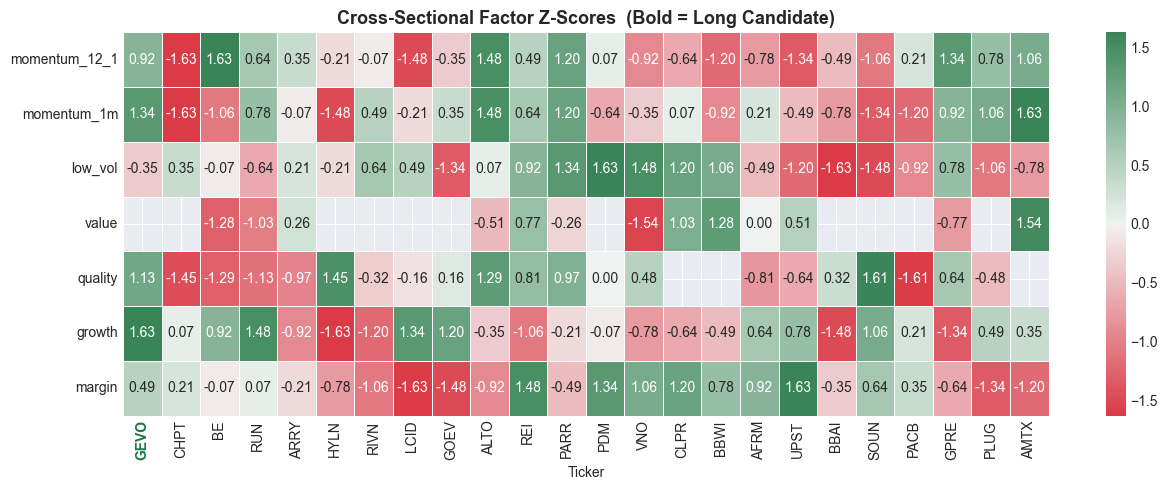

In [9]:
# Factor score heatmap
fig, ax = plt.subplots(figsize=(13, 5))
plot_data = factor_z.drop(columns='composite').T
cmap = sns.diverging_palette(10, 140, as_cmap=True)
sns.heatmap(plot_data, annot=True, fmt='.2f', cmap=cmap, center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
for label in ax.get_xticklabels():
    if label.get_text() == LONG_CANDIDATE:
        label.set_fontweight('bold')
        label.set_color('#1a7a4a')
ax.set_title('Cross-Sectional Factor Z-Scores  (Bold = Long Candidate)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_factor_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Market + Sector Beta Regression

For each stock: `r_i = α + β_mkt·r_mkt + β_sec·r_sec + ε`

Residuals `ε` represent idiosyncratic returns stripped of market and sector exposure.

In [10]:
betas     = {}
residuals = {}
alphas    = {}
rsquareds = {}

common_idx = stock_ret.index.intersection(mkt_ret.index).intersection(sec_ret.index)
X_base = add_constant(pd.DataFrame({'mkt': mkt_ret.loc[common_idx],
                                     'sec': sec_ret.loc[common_idx]}))

for ticker in ALL_STOCKS:
    y = stock_ret[ticker].loc[common_idx].dropna()
    X = X_base.loc[y.index]
    model = OLS(y, X).fit()
    betas[ticker]     = {'alpha': model.params['const'],
                         'beta_mkt': model.params['mkt'],
                         'beta_sec': model.params['sec']}
    alphas[ticker]    = model.params['const'] * 252      # annualised alpha
    residuals[ticker] = model.resid
    rsquareds[ticker] = model.rsquared

beta_df  = pd.DataFrame(betas).T
resid_df = pd.DataFrame(residuals)

beta_df.index.name = 'Ticker'
beta_df['annualised_alpha'] = pd.Series(alphas)
beta_df['r_squared']        = pd.Series(rsquareds)

beta_df.to_parquet(DATA_DIR + 'betas.parquet')
resid_df.to_parquet(DATA_DIR + 'residuals.parquet')

print('OLS Results:')
display(beta_df.round(4))

OLS Results:


,alpha,beta_mkt,beta_sec,annualised_alpha,r_squared
Ticker,,,,,
GEVO,0.0003,2.7928,-0.7085,0.0812,0.1244
CHPT,-0.0039,1.5730,0.3450,-0.9708,0.1911
BE,0.0023,1.3958,0.5068,0.5677,0.1796
RUN,0.0003,2.8889,-0.6763,0.0876,0.1374
ARRY,0.0006,1.9100,-0.3004,0.1488,0.1035
HYLN,-0.0002,1.6949,0.1997,-0.0491,0.1522
RIVN,-0.0007,2.0136,-0.1834,-0.1651,0.1755
LCID,-0.0028,1.9225,-0.1268,-0.6965,0.1479
GOEV,-0.0064,1.8230,-0.6300,-1.6226,0.0237


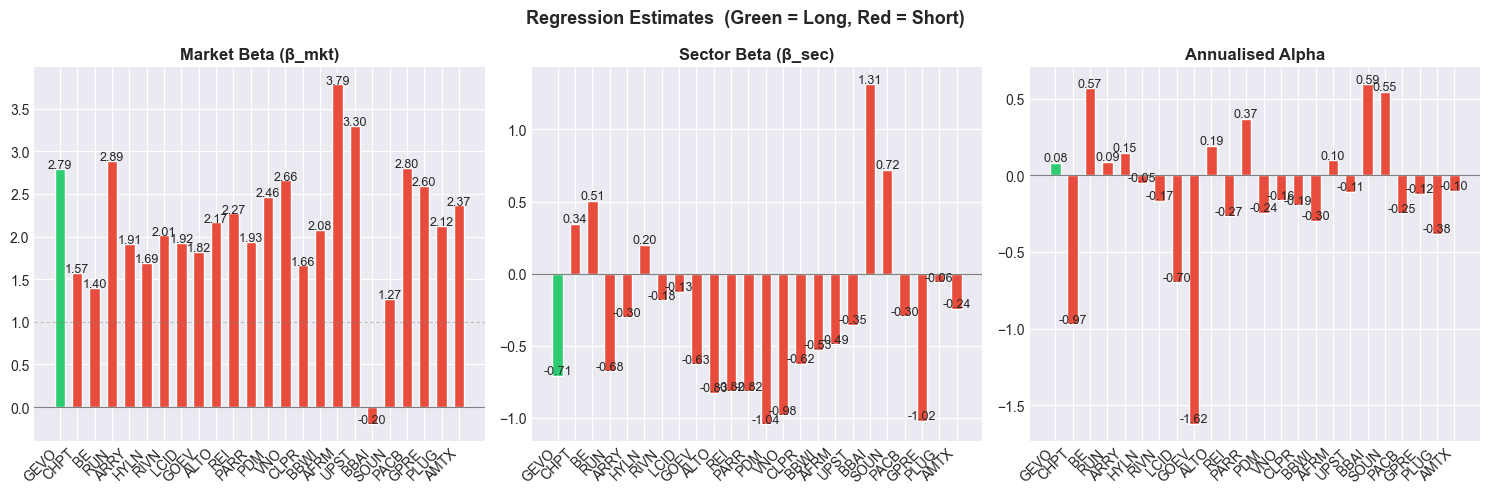

In [11]:
# Beta bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cols   = ['beta_mkt', 'beta_sec', 'annualised_alpha']
titles = ['Market Beta (β_mkt)', 'Sector Beta (β_sec)', 'Annualised Alpha']
colors = ['#2ecc71' if t == LONG_CANDIDATE else '#e74c3c' for t in beta_df.index]

for ax, col, title in zip(axes, cols, titles):
    vals = beta_df[col]
    bars = ax.bar(vals.index, vals, color=colors, edgecolor='white', width=0.6)
    ax.axhline(0, color='black', lw=0.8, alpha=0.5)
    if col == 'beta_mkt':
        ax.axhline(1, color='grey', lw=0.8, linestyle='--', alpha=0.5, label='β=1')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=45, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Regression Estimates  (Green = Long, Red = Short)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_betas.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Residual Correlation & Clustering

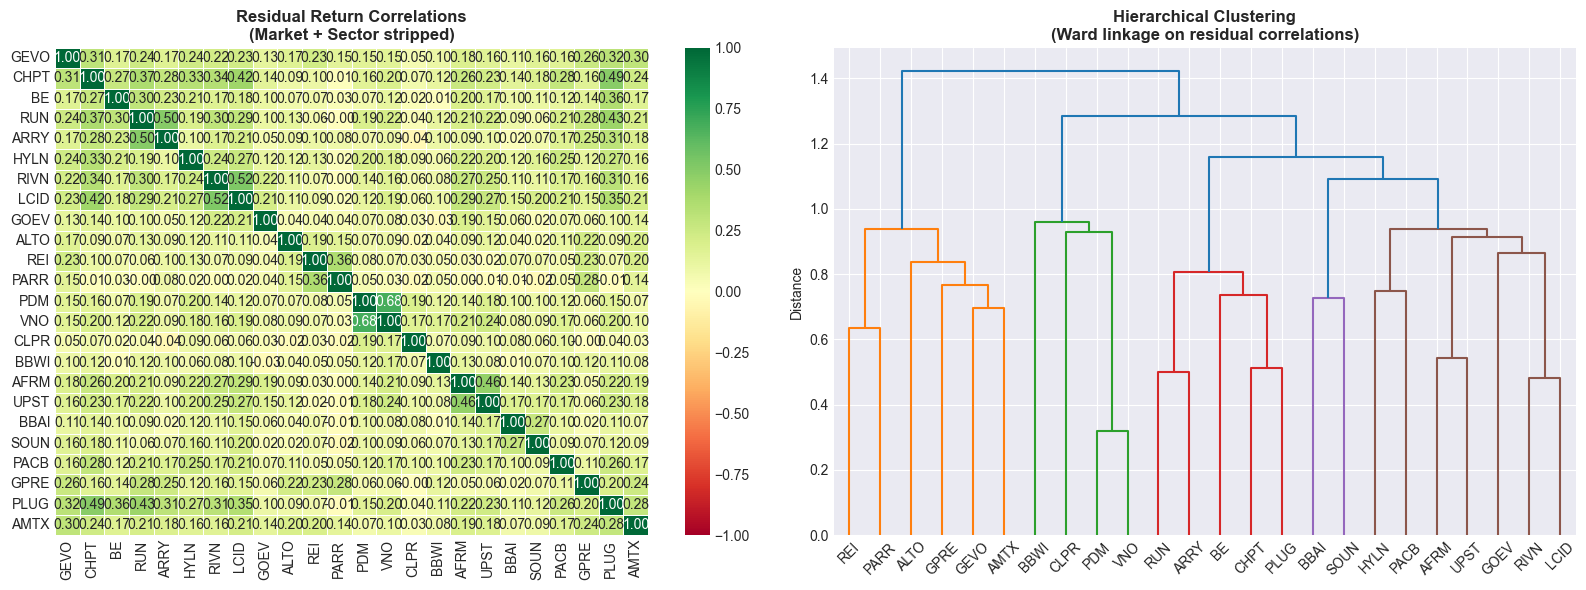

Cluster assignments:


,Cluster,Role
Ticker,,
GEVO,1,LONG
CHPT,3,SHORT
BE,3,SHORT
RUN,3,SHORT
ARRY,3,SHORT
HYLN,3,SHORT
RIVN,3,SHORT
LCID,3,SHORT
GOEV,3,SHORT


In [12]:
resid_corr = resid_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(resid_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            annot_kws={'size': 10}, linewidths=0.5)
axes[0].set_title('Residual Return Correlations\n(Market + Sector stripped)',
                  fontsize=12, fontweight='bold')

# Hierarchical clustering dendrogram
dist_matrix = 1 - resid_corr.abs()
np.fill_diagonal(dist_matrix.values, 0)
dist_condensed = squareform(dist_matrix.values)
Z = linkage(dist_condensed, method='ward')
dendrogram(Z, labels=resid_corr.columns.tolist(),
           ax=axes[1], leaf_rotation=45)
axes[1].set_title('Hierarchical Clustering\n(Ward linkage on residual correlations)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Distance')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_residual_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Assign clusters
n_clusters = min(3, len(ALL_STOCKS) - 1)
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')
cluster_df = pd.DataFrame({'Ticker': resid_corr.columns, 'Cluster': cluster_labels}).set_index('Ticker')
cluster_df['Role'] = ['LONG' if t == LONG_CANDIDATE else 'SHORT' for t in cluster_df.index]
print('Cluster assignments:')
display(cluster_df)

## 4. PCA on Residuals

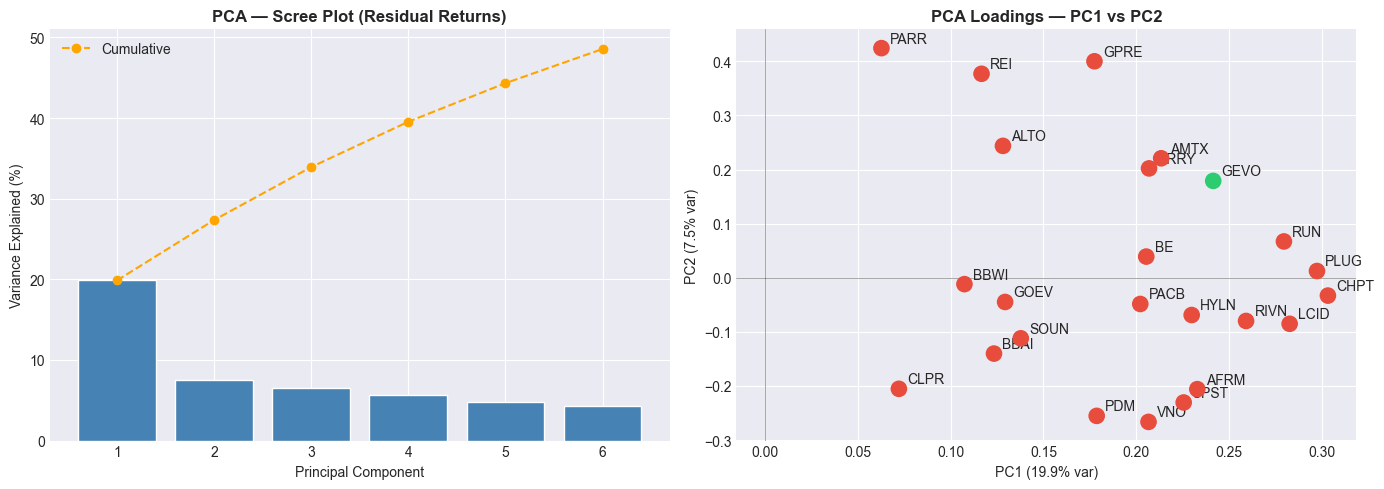

Saved pca_scores.parquet, clusters.parquet

Notebook 02 complete. Run 03_ml_selection.ipynb next.


In [13]:
scaler  = StandardScaler()
X_resid = scaler.fit_transform(resid_df.dropna())

pca = PCA(n_components=min(len(ALL_STOCKS), 6))
pca.fit(X_resid)

# Explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='white')
axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1),
             np.cumsum(pca.explained_variance_ratio_) * 100,
             'o--', color='orange', label='Cumulative')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('PCA — Scree Plot (Residual Returns)', fontsize=12, fontweight='bold')
axes[0].legend()

# Loadings for PC1 and PC2
loadings = pd.DataFrame(pca.components_[:2].T,
                        index=resid_df.columns,
                        columns=['PC1', 'PC2'])
colors = ['#2ecc71' if t == LONG_CANDIDATE else '#e74c3c' for t in loadings.index]
axes[1].scatter(loadings['PC1'], loadings['PC2'], c=colors, s=120, zorder=5)
for ticker, row in loadings.iterrows():
    axes[1].annotate(ticker, (row['PC1'], row['PC2']),
                     textcoords='offset points', xytext=(6, 4), fontsize=10)
axes[1].axhline(0, color='black', lw=0.6, alpha=0.4)
axes[1].axvline(0, color='black', lw=0.6, alpha=0.4)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[1].set_title('PCA Loadings — PC1 vs PC2', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_pca_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Save PCA scores for downstream use
pca_scores = pd.DataFrame(pca.transform(X_resid),
                           index=resid_df.dropna().index,
                           columns=[f'PC{i+1}' for i in range(pca.n_components_)])
pca_scores.to_parquet(DATA_DIR + 'pca_scores.parquet')
cluster_df.to_parquet(DATA_DIR + 'clusters.parquet')
print('Saved pca_scores.parquet, clusters.parquet')
print('\nNotebook 02 complete. Run 03_ml_selection.ipynb next.')